In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from IPython.display import display

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url, header=0)

# A little cleanup
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Translate text to math (One-Hot Encoding)
df_clean = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True) 

# Isolate clues (X) and answers (y)
y = df_clean['Survived']
X = df_clean.drop(columns=['Survived'])

# Generate The Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

# Initialize and train the decision tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

print("Data fetched, cleaned, and Decision Tree trained successfully!")

# Aks the tree to predict the fates  of the unseen test passengers
tree_predictions = tree_model.predict(X_test)

# Grade the predictions
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_matrix = confusion_matrix(y_test, tree_predictions)

# 3. Display the results
print("--- Decision Tree Accuracy ---")
display(tree_accuracy * 100)

print("\n--- Confusion Matrix ---")
display(tree_matrix)

Data fetched, cleaned, and Decision Tree trained successfully!
--- Decision Tree Accuracy ---


77.09497206703911


--- Confusion Matrix ---


array([[93, 19],
       [22, 45]])

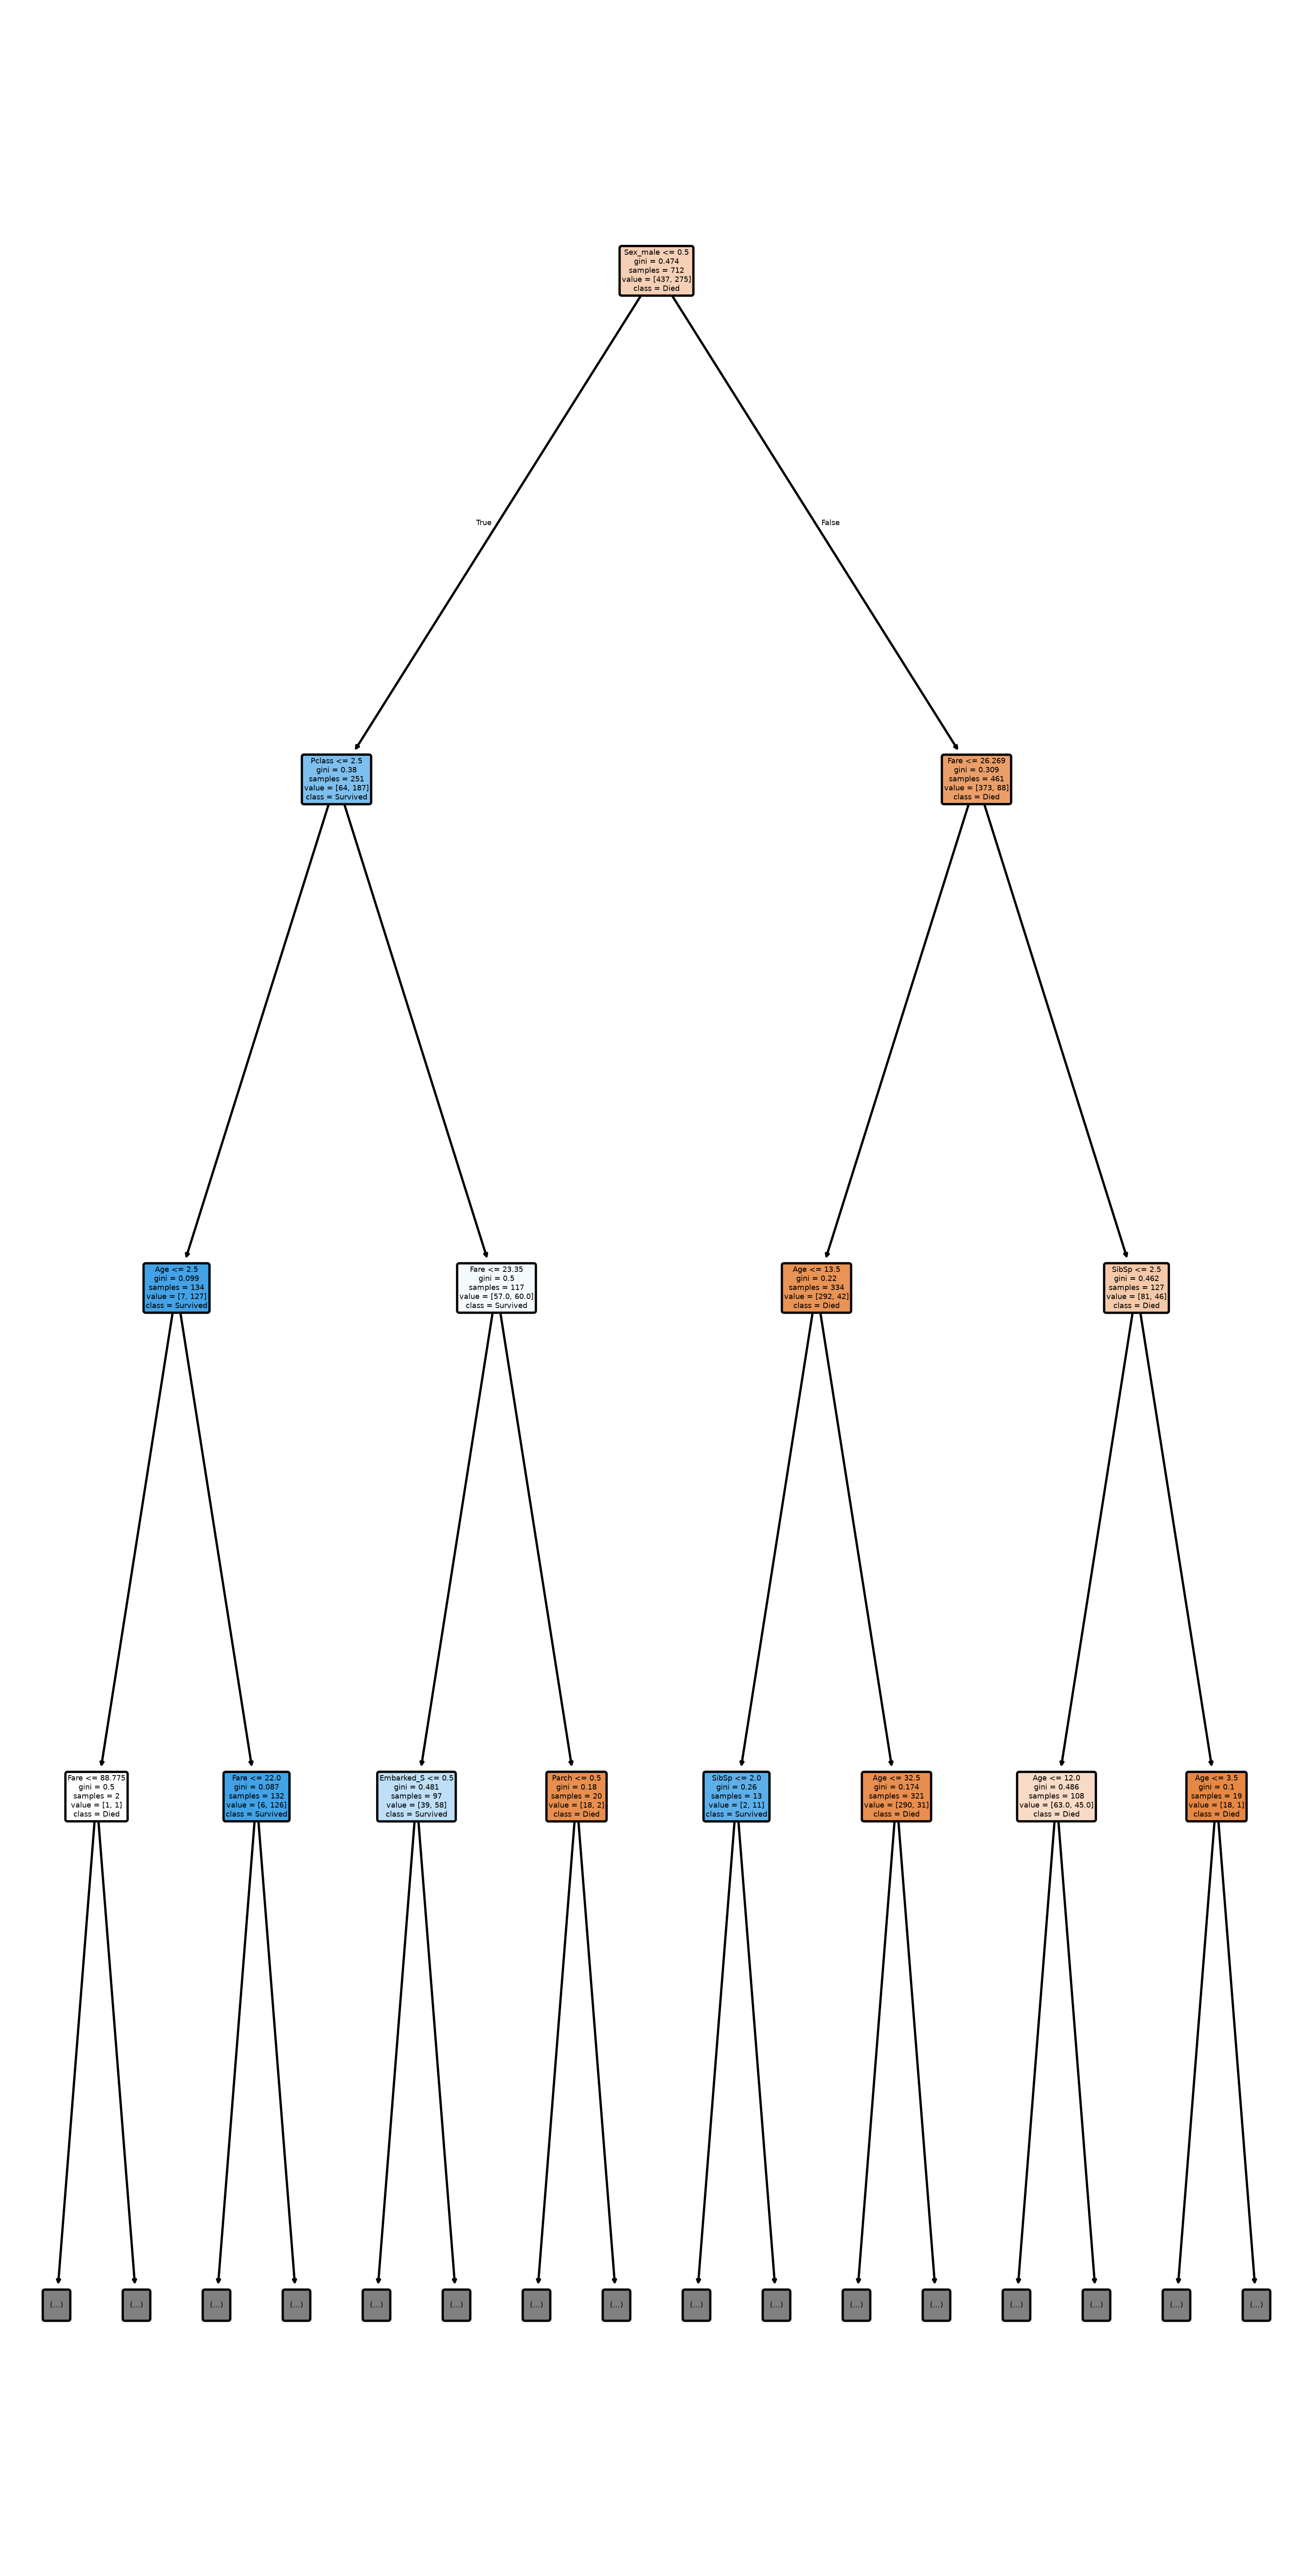

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set up a massive canvas so the tree is readable
plt.figure(figsize=(10, 20), dpi=400)

# Draw the tree
plot_tree(tree_model,
          feature_names=X.columns, # Labels the questions with our column names
          class_names=['Died', 'Survived'], # Translates 0 and 1 back to english
          filled=True, # Colors the boxes based on predictions
          rounded=True, # Makes it look slightly nicer
          max_depth=3 # We limit the drawings to 3 levels deep so it fits on the screen
          )

# Render the image
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a forest of 100 trees, limiting their depth so they don't overfit
forest_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Train the entire forest
forest_model.fit(X_train, y_train)

# Ask the forest to predict the fates of the unseen test passengers
forest_predictions = forest_model.predict(X_test)

# Grade the predictions
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_matrix = confusion_matrix(y_test, forest_predictions)

# Display the results
print("--- Random Forest Accuracy ---")
display(forest_accuracy * 100)

print("\n--- Confusion Matrix ---")
display(forest_matrix)